# Regression Analysis: News Topics → Stock Returns
## Chen (2025) Framework - BERTopic Integration

**Objective**: Analyze impact of news topics on stock returns for 30 G-SIB banks

### Workflow:
1. Load stock returns from `Data/eodhd_tickers_performance.csv`
2. Load topic assignments from BERTopic output folder
3. Merge on date and extract topic information from headline metadata
4. Aggregate topics to daily level per ticker
5. Run OlS regression: `return ~ topics`
6. Save results to `Outputs/Regression_Results/`

### Data Sources:
- **Stock Returns**: `Code/Data/eodhd_tickers_performance.csv` (daily OHLCV)
- **Topics**: `Code/Outputs/eodhd_BERTopic_FinBert/*/row_level/row_topic_assignments_all.csv`
- **Stock Tickers**: 29 G-SIB banks (JPM, BAC, C, HSBC, etc.)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# For regression
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

# Set paths
base_path = Path('.')
data_path = base_path / 'Data'
output_path = base_path / 'Outputs'
regression_output = base_path / 'Outputs' / 'Regression_Results_FinBert_adj_return'

# Create output directory
regression_output.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported")
print(f"✓ Output path: {regression_output}")


✓ Libraries imported
✓ Output path: Outputs\Regression_Results_FinBert_adj_return


## Section 1: Load Stock Returns Data

In [47]:
# Load stock returns data
stock_returns = pd.read_csv(data_path / 'eodhd_tickers_performance.csv')

# Convert date to datetime
stock_returns['date'] = pd.to_datetime(stock_returns['date'])

# Calculate daily returns if not already present
if stock_returns['daily_adj_return'].isna().all():
    stock_returns['daily_adj_return'] = stock_returns.groupby('ticker')['adjusted_close'].pct_change() * 100
else:
    stock_returns['daily_adj_return'] = stock_returns['daily_adj_return'].fillna(
        stock_returns.groupby('ticker')['adjusted_close'].pct_change() * 100
    )

# Remove NaN returns (first obs per ticker)
stock_returns = stock_returns.dropna(subset=['daily_adj_return'])
print(f"✓ Stock returns loaded: {stock_returns.shape[0]} records")
print(f"✓ Date range: {stock_returns['date'].min()} to {stock_returns['date'].max()}")
print(f"✓ Unique tickers: {stock_returns['ticker'].nunique()}")
print(f"\nStock returns summary:")
print(stock_returns[['date', 'ticker', 'adjusted_close', 'daily_adj_return']].head(10))


✓ Stock returns loaded: 80268 records
✓ Date range: 2014-02-19 00:00:00 to 2026-05-08 00:00:00
✓ Unique tickers: 27

Stock returns summary:
         date ticker  adjusted_close  daily_adj_return
26 2014-02-19  ACGBY          4.7804         -0.844206
27 2014-02-19    BAC         12.6883         -1.639560
28 2014-02-19  BACHY          4.5157         -0.355267
29 2014-02-19    BCS         11.8166         -1.895408
30 2014-02-19     BK         23.1656         -1.983964
31 2014-02-19  BNPQY         21.4580         -1.018507
32 2014-02-19      C         35.5164         -2.409778
33 2014-02-19  CICHY          6.2386          0.000000
34 2014-02-19     DB         33.7870         -2.105824
35 2014-02-19     GS        128.9216         -0.844183


## Section 2: Load Topic Assignments from Output Folder

In [48]:
# Specifically use eodhd_BERTopic_FinBert folder
bertopic_folder = output_path / 'eodhd_BERTopic_FinBert'

if not bertopic_folder.exists():
    raise FileNotFoundError(f"BERTopic folder not found: {bertopic_folder}")

# Find the timestamp subfolder (most recent if multiple exist)
timestamp_folders = list(bertopic_folder.glob('*/'))
if not timestamp_folders:
    raise FileNotFoundError(f"No timestamp subfolder found in {bertopic_folder}")

timestamp_folder = sorted(timestamp_folders, key=lambda x: os.path.getmtime(x), reverse=True)[0]
topics_file = timestamp_folder / 'row_level' / 'row_topic_assignments_all.csv'

print(f"Loading topics from: {topics_file}")

# Load topics
topics_df = pd.read_csv(topics_file)

# Only use Test Split
topics_df = topics_df[topics_df['split'] == 'test'].copy()
print(f"✓ Topics loaded: {topics_df.shape[0]} records (Test Split only)")

# Parse date from topics_df (assuming it has a date column)
topics_df['date'] = pd.to_datetime(topics_df['date'])

# IMPORTANT: The row_topic_assignments_all.csv does NOT have ticker info
# We need to merge it back from the original model input data
print(f"✓ Topics columns: {list(topics_df.columns)}")
print(f"✓ Topics shape: {topics_df.shape}")

# Load the original model input to get ticker mapping
model_input = pd.read_csv(data_path / 'eodhd_model_input.csv')
model_input['date'] = pd.to_datetime(model_input['date'])
print(f"\nModel input columns: {list(model_input.columns)}")

# Create a mapping of (date, headline) -> ticker
# Note: Some headlines appear multiple times across different tickers
# We'll keep one ticker per headline for simplicity (first occurrence)
headline_ticker_map = model_input.groupby('headline').first()[['stock']].reset_index()
headline_ticker_map = headline_ticker_map.rename(columns={'stock': 'ticker'})

print(f"\nHeadline-to-ticker mapping: {len(headline_ticker_map)} unique headlines")

# Merge ticker into topics
topics_df = topics_df.merge(headline_ticker_map, on='headline', how='left')

# Check how many we matched
matched = topics_df['ticker'].notna().sum()
total = len(topics_df)
print(f"Matched {matched}/{total} headlines to tickers ({100*matched/total:.1f}%)")

# Remove rows without ticker match
topics_with_ticker = topics_df[topics_df['ticker'].notna()].copy()
print(f"Topics with ticker: {len(topics_with_ticker)}")

print(f"\nTicker distribution in topics:")
print(topics_with_ticker['ticker'].value_counts().head(10))


Loading topics from: Outputs\eodhd_BERTopic_FinBert\20260504_230615\row_level\row_topic_assignments_all.csv
✓ Topics loaded: 10036 records (Test Split only)
✓ Topics columns: ['split', 'row_index', 'date', 'headline', 'topic']
✓ Topics shape: (10036, 5)

Model input columns: ['stock', 'date', 'date_only', 'headline', 'headline_raw']

Headline-to-ticker mapping: 65402 unique headlines
Matched 10036/10036 headlines to tickers (100.0%)
Topics with ticker: 10036

Ticker distribution in topics:
ticker
JPM     1964
HSBC    1254
BAC     1133
GS       953
MS       902
C        604
UBS      586
WFC      522
BCS      440
SAN      242
Name: count, dtype: int64


## Section 3: Aggregate Topics to Daily Level per Ticker

In [49]:
# Use the topics_with_ticker from Section 2 (already has ticker from model_input merge)
print(f"Topics with ticker: {len(topics_with_ticker)}")
print(f"Columns: {list(topics_with_ticker.columns)}")
print(f"Date range: {topics_with_ticker['date'].min()} to {topics_with_ticker['date'].max()}")
print(f"\nTicker distribution:")
print(topics_with_ticker['ticker'].value_counts())


Topics with ticker: 10036
Columns: ['split', 'row_index', 'date', 'headline', 'topic', 'ticker']
Date range: 2026-01-12 00:00:00+00:00 to 2026-05-01 14:06:17+00:00

Ticker distribution:
ticker
JPM      1964
HSBC     1254
BAC      1133
GS        953
MS        902
C         604
UBS       586
WFC       522
BCS       440
SAN       242
BNPQY     200
DB        189
ING       185
STT       164
RY        145
BK        139
MUFG      128
TD        104
MFG        60
SCBFF      35
SCGLY      29
SMFG       28
IDCBY      11
CICHY       7
BACHY       6
ACGBY       5
BCMXY       1
Name: count, dtype: int64


## Section 4: Pivot Topics to Daily Level per Ticker

In [50]:
# Create lagged date for topics (shift forward by 1 day)
topic_pivot_lagged = topic_pivot.copy()
topic_pivot_lagged['merge_date'] = topic_pivot_lagged['date'] + pd.Timedelta(days=1)

# ==========================================
# CRITICAL FIX 3: Roll Weekend News to Monday!
# ==========================================
# If merge_date falls on Saturday (day 5), shift 2 days to Monday
is_saturday = topic_pivot_lagged['merge_date'].dt.dayofweek == 5
topic_pivot_lagged.loc[is_saturday, 'merge_date'] += pd.Timedelta(days=2)

# If merge_date falls on Sunday (day 6), shift 1 day to Monday
is_sunday = topic_pivot_lagged['merge_date'].dt.dayofweek == 6
topic_pivot_lagged.loc[is_sunday, 'merge_date'] += pd.Timedelta(days=1)

# Convert continuous topic prevalence to binary dummies (presence = prevalence > 0)
topic_cols_base = [c for c in topic_pivot_lagged.columns if c.startswith('topic_')]
print(f"Converting {len(topic_cols_base)} topics from prevalence to binary dummies...")

for col in topic_cols_base:
    topic_pivot_lagged[col] = (topic_pivot_lagged[col] > 0).astype(int)

# Rename topic columns to indicate they are lagged dummy variables
topic_cols_lagged = {col: f'{col}_lag1' for col in topic_cols_base}
topic_pivot_lagged = topic_pivot_lagged.rename(columns=topic_cols_lagged)

# ==========================================
# CRITICAL FIX 4: Aggregate the Weekend Block
# Group by merge_date and ticker to combine Fri/Sat/Sun into a single Monday row.
# .max() ensures if a dummy was 1 on any weekend day, it stays 1.
# ==========================================
topic_pivot_lagged = topic_pivot_lagged.groupby(['merge_date', 'ticker'])[list(topic_cols_lagged.values()) + ['total_articles']].max().reset_index()

print(f"✓ Created 1-day lagged binary topic dummies (with Weekend rolling):")
print(f"  Binary topics (0/1): {len(topic_cols_base)} columns")

# Merge: tomorrow's stock returns (date t+1) with today's topic dummies (date t)
regression_data = stock_returns_merge.merge(
    topic_pivot_lagged[['merge_date', 'ticker', *topic_cols_lagged.values(), 'total_articles']],
    left_on=['date', 'ticker'],
    right_on=['merge_date', 'ticker'],
    how='left'  
)

Converting 298 topics from prevalence to binary dummies...
✓ Created 1-day lagged binary topic dummies (with Weekend rolling):
  Binary topics (0/1): 298 columns


## Section 5: Merge Stock Returns with Topic Data

In [51]:
# Select only necessary columns from stock returns
stock_returns_merge = stock_returns[['date', 'ticker', 'adjusted_close', 'daily_adj_return']].copy()

# ==========================================
# CRITICAL FIX 1: Normalize dates to exactly midnight!
# ==========================================
stock_returns_merge['date'] = stock_returns_merge['date'].dt.tz_localize(None).dt.normalize()
topic_pivot['date'] = topic_pivot['date'].dt.tz_localize(None).dt.normalize()

# ==========================================
# CRITICAL FIX 2: Crop the stock data to the test split window
# ==========================================
# Find the start and end dates of the test split
min_topic_date = topic_pivot['date'].min()
max_topic_date = topic_pivot['date'].max()

# Filter stock returns to ONLY the 4-month test window 
# (Adding 1 day to max_date because we predict tomorrow's return)
stock_returns_merge = stock_returns_merge[
    (stock_returns_merge['date'] > min_topic_date) & 
    (stock_returns_merge['date'] <= max_topic_date + pd.Timedelta(days=1))
]
print(f"✓ Cropped stock history to test window: {min_topic_date.date()} to {(max_topic_date + pd.Timedelta(days=1)).date()}")

# IMPORTANT: Chen (2025) Framework - Convert Topic Prevalence to Binary Dummies
# Create lagged date for topics (shift forward by 1 day)
topic_pivot_lagged = topic_pivot.copy()
topic_pivot_lagged['merge_date'] = topic_pivot_lagged['date'] + pd.Timedelta(days=1)

# Convert continuous topic prevalence to binary dummies (presence = prevalence > 0)
topic_cols_base = [c for c in topic_pivot_lagged.columns if c.startswith('topic_')]
print(f"Converting {len(topic_cols_base)} topics from prevalence to binary dummies...")

for col in topic_cols_base:
    # Convert: if prevalence > 0, then topic is present (1), else absent (0)
    topic_pivot_lagged[col] = (topic_pivot_lagged[col] > 0).astype(int)

# Rename topic columns to indicate they are lagged dummy variables
topic_cols_lagged = {col: f'{col}_lag1' for col in topic_cols_base}
topic_pivot_lagged = topic_pivot_lagged.rename(columns=topic_cols_lagged)

print(f"✓ Created 1-day lagged binary topic dummies:")
print(f"  Binary topics (0/1): {len(topic_cols_base)} columns")
print(f"  Lagged dummies: {list(topic_cols_lagged.values())[:5]}... (showing first 5)")

# Merge: tomorrow's stock returns (date t+1) with today's topic dummies (date t)
regression_data = stock_returns_merge.merge(
    topic_pivot_lagged[['merge_date', 'ticker', *topic_cols_lagged.values(), 'total_articles']],
    left_on=['date', 'ticker'],
    right_on=['merge_date', 'ticker'],
    how='left'  # Safe to use 'left' now because we cropped the stock data above!
)

# Drop the merge_date column (redundant with date)
regression_data = regression_data.drop('merge_date', axis=1)

# Fill NaN lagged topic dummies with 0 (topic not present on prior day)
topic_cols = [c for c in regression_data.columns if c.startswith('topic_') and c.endswith('_lag1')]
for col in topic_cols:
    regression_data[col] = regression_data[col].fillna(0).astype(int)

print(f"\n✓ Merged regression data with 1-day lagged binary dummies:")
print(f"✓ Total records (TEST SPLIT ONLY): {regression_data.shape[0]}")
print(f"✓ Columns: {regression_data.shape[1]}")
print(f"✓ Binary topic dummy columns: {len(topic_cols)}")

✓ Cropped stock history to test window: 2026-01-12 to 2026-05-02
Converting 298 topics from prevalence to binary dummies...
✓ Created 1-day lagged binary topic dummies:
  Binary topics (0/1): 298 columns
  Lagged dummies: ['topic_0_lag1', 'topic_1_lag1', 'topic_2_lag1', 'topic_3_lag1', 'topic_4_lag1']... (showing first 5)

✓ Merged regression data with 1-day lagged binary dummies:
✓ Total records (TEST SPLIT ONLY): 3734
✓ Columns: 303
✓ Binary topic dummy columns: 298


## Section 6: Exploratory Data Analysis

DAILY ADJUSTED RETURNS STATISTICS BY TICKER
        count      mean       std        min       25%       50%       75%  \
ticker                                                                       
ACGBY    76.0  0.112817  1.328875  -3.197109 -0.733549  0.187387  0.823675   
BAC     274.0  0.028464  1.458154  -4.722724 -0.974065  0.209639  0.759400   
BACHY    76.0  0.171913  1.182490  -2.289157 -0.444327  0.094632  0.683251   
BCMXY    76.0  0.063080  2.092494 -13.012433  0.000000  0.000000  0.000000   
BCS     146.0 -0.251763  2.203335  -5.900901 -2.052643 -0.041806  1.242977   
BK       92.0  0.286022  1.499323  -5.579250 -0.709306  0.294354  1.350325   
BNPQY   105.0  0.250102  1.949977  -5.395545 -0.859291  0.304820  1.733478   
C       203.0  0.363377  2.460604  -5.315597 -1.074494  0.289979  1.628364   
CICHY    76.0  0.184450  1.291615  -3.011472 -0.564868  0.185070  0.674354   
DB       91.0 -0.274192  2.340394  -6.628608 -1.959812  0.070497  1.135249   
GS      222.0  0.137

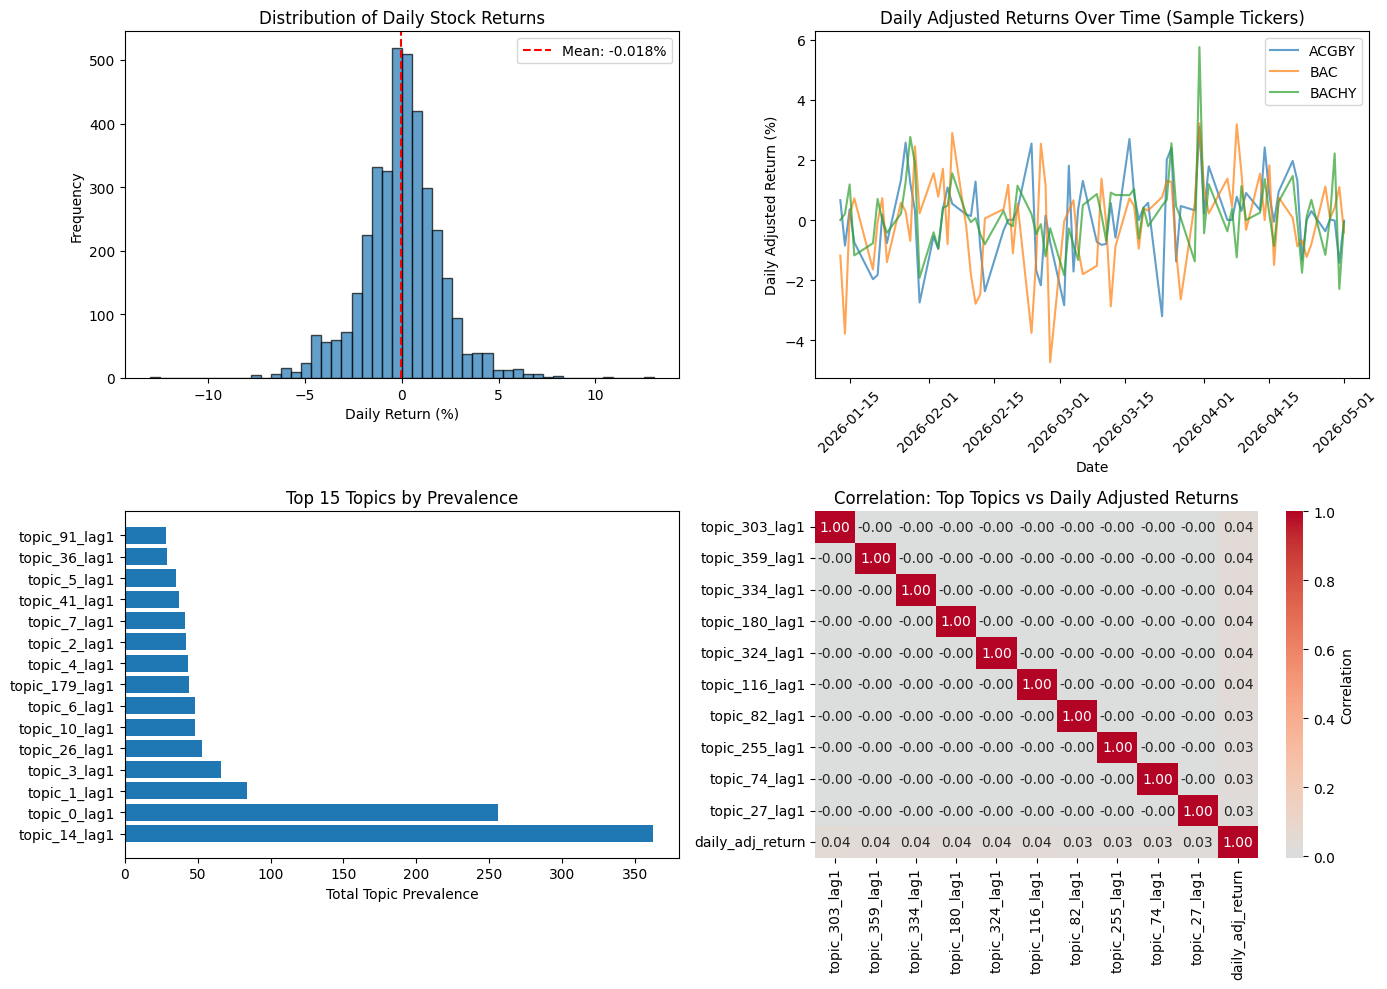

In [52]:
# Summary statistics for daily returns
print("="*70)
print("DAILY ADJUSTED RETURNS STATISTICS BY TICKER")
print("="*70)
returns_summary = regression_data.groupby('ticker')['daily_adj_return'].describe()
print(returns_summary)

# Summary statistics for lagged topics (t-1)
print("\n" + "="*70)
print("LAGGED TOPIC PREVALENCE STATISTICS (t-1)")
print("="*70)
topic_summary = regression_data[topic_cols].describe()
print(topic_summary)

# Correlation between lagged topics (t-1) and daily returns (t)
print("\n" + "="*70)
print("CORRELATION: LAGGED TOPICS (t-1) vs DAILY ADJUSTEDRETURNS (t)")
print("="*70)
correlation_matrix = regression_data[[*topic_cols, 'daily_adj_return']].corr()
topic_return_corr = correlation_matrix[['daily_adj_return']].drop('daily_adj_return').sort_values('daily_adj_return', ascending=False)
print(topic_return_corr)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of daily returns
axes[0, 0].hist(regression_data['daily_adj_return'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Daily Return (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Stock Returns')
axes[0, 0].axvline(regression_data['daily_adj_return'].mean(), color='red', linestyle='--', label=f'Mean: {regression_data["daily_adj_return"].mean():.3f}%')
axes[0, 0].legend()

# Plot 2: Daily returns over time (sample of tickers)
sample_tickers = regression_data['ticker'].unique()[:3]
for ticker in sample_tickers:
    ticker_data = regression_data[regression_data['ticker'] == ticker].sort_values('date')
    axes[0, 1].plot(ticker_data['date'], ticker_data['daily_adj_return'], label=ticker, alpha=0.7)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Daily Adjusted Return (%)')
axes[0, 1].set_title('Daily Adjusted Returns Over Time (Sample Tickers)')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Topic prevalence distribution
topic_prevalence_plot = regression_data[topic_cols].sum().sort_values(ascending=False).head(15)
axes[1, 0].barh(range(len(topic_prevalence_plot)), topic_prevalence_plot.values)
axes[1, 0].set_yticks(range(len(topic_prevalence_plot)))
axes[1, 0].set_yticklabels(topic_prevalence_plot.index)
axes[1, 0].set_xlabel('Total Topic Prevalence')
axes[1, 0].set_title('Top 15 Topics by Prevalence')

# Plot 4: Correlation heatmap (top topics)
top_topics = topic_return_corr.head(10).index.tolist()
corr_subset = regression_data[[*top_topics, 'daily_adj_return']].corr()
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation: Top Topics vs Daily Adjusted Returns')

plt.tight_layout()
plt.savefig(regression_output / '01_eda_summary.png', dpi=300, bbox_inches='tight')
print("✓ EDA visualization saved: 01_eda_summary.png")
plt.show()


## Section 7: Regression Model (OLS with Fixed Effects)

In [53]:
# Prepare data for regression (Chen 2025 Framework)
# Remove first observation per ticker (no prior day topics available)
# Also remove any rows with NaN daily returns
regression_model_data = regression_data.dropna(subset=['daily_adj_return'])
regression_model_data = regression_model_data.dropna(subset=topic_cols, how='all')  # Remove rows with all NaN topics
print(regression_model_data.shape)

# Select top topics (by variance) to avoid multicollinearity
# Keep only topics with meaningful variation
topic_cols_clean = [c for c in topic_cols if regression_model_data[c].std() > 0]

print(f"✓ Topics in model: {len(topic_cols_clean)} (with non-zero variance)")

# Build regression formula - Chen (2025) specification
# Model: return(t) ~ topic_assignment(t-1)
# Interpretation: Tomorrow's return predicted by today's news topics
formula = f"daily_adj_return ~ {' + '.join(topic_cols_clean)} + C(ticker)"  # Use ALL topics

print(f"\n{'='*70}")
print("REGRESSION SPECIFICATION: Chen (2025) - 1-Day Lag Framework")
print(f"{'='*70}")
print(f"Dependent Variable: daily_adj_return(t) = Adjusted return on day t")
print(f"Independent Variables: topic_X_lag1 = Topic assignments from day t-1")
print(f"Sample: {len(regression_model_data)} observations across {regression_model_data['ticker'].nunique()} banks")
print(f"Total topics in model: {len(topic_cols_clean)}")
print(f"\nFormula (first 300 chars):\n{formula[:300]}...\n")

# Run OLS regression
print("Running OLS regression...")
try:
    model = ols(formula, data=regression_model_data).fit()
    
    # Display summary
    print("\n" + "="*70)
    print("REGRESSION RESULTS SUMMARY")
    print("="*70)
    print(model.summary())
    
    # Save detailed summary
    summary_text = str(model.summary())
    with open(regression_output / '02_regression_summary.txt', 'w') as f:
        f.write(summary_text)
    
    print("\n✓ Regression summary saved: 02_regression_summary.txt")
    
    # Extract coefficients
    coefficients = model.params.drop('Intercept', errors='ignore')
    print(f"\n✓ Model R²: {model.rsquared:.4f}")
    print(f"✓ Adjusted R²: {model.rsquared_adj:.4f}")
    print(f"✓ F-statistic: {model.fvalue:.2f} (p-value: {model.f_pvalue:.2e})")
    
except Exception as e:
    print(f"Error in regression: {e}")
    import traceback
    traceback.print_exc()


(3734, 303)
✓ Topics in model: 286 (with non-zero variance)

REGRESSION SPECIFICATION: Chen (2025) - 1-Day Lag Framework
Dependent Variable: daily_adj_return(t) = Adjusted return on day t
Independent Variables: topic_X_lag1 = Topic assignments from day t-1
Sample: 3734 observations across 27 banks
Total topics in model: 286

Formula (first 300 chars):
daily_adj_return ~ topic_0_lag1 + topic_1_lag1 + topic_2_lag1 + topic_3_lag1 + topic_4_lag1 + topic_5_lag1 + topic_6_lag1 + topic_7_lag1 + topic_8_lag1 + topic_9_lag1 + topic_10_lag1 + topic_11_lag1 + topic_13_lag1 + topic_14_lag1 + topic_15_lag1 + topic_16_lag1 + topic_17_lag1 + topic_18_lag1 + top...

Running OLS regression...

REGRESSION RESULTS SUMMARY
                            OLS Regression Results                            
Dep. Variable:       daily_adj_return   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statisti

## Section 8: Model Diagnostics and Visualization


TOPIC COEFFICIENTS (Sorted by Effect Size)
Positive coefficients = Topic increases returns
Negative coefficients = Topic decreases returns
----------------------------------------------------------------------
topic_303_lag1    5.044782
topic_359_lag1    4.959830
topic_334_lag1    4.449782
topic_180_lag1    4.419397
topic_128_lag1    3.432490
                    ...   
topic_188_lag1   -3.889981
topic_285_lag1   -3.984284
topic_330_lag1   -4.097760
topic_126_lag1   -5.549118
topic_173_lag1   -6.118051
Length: 286, dtype: float64

✓ Diagnostics visualization saved: 03_regression_diagnostics.png


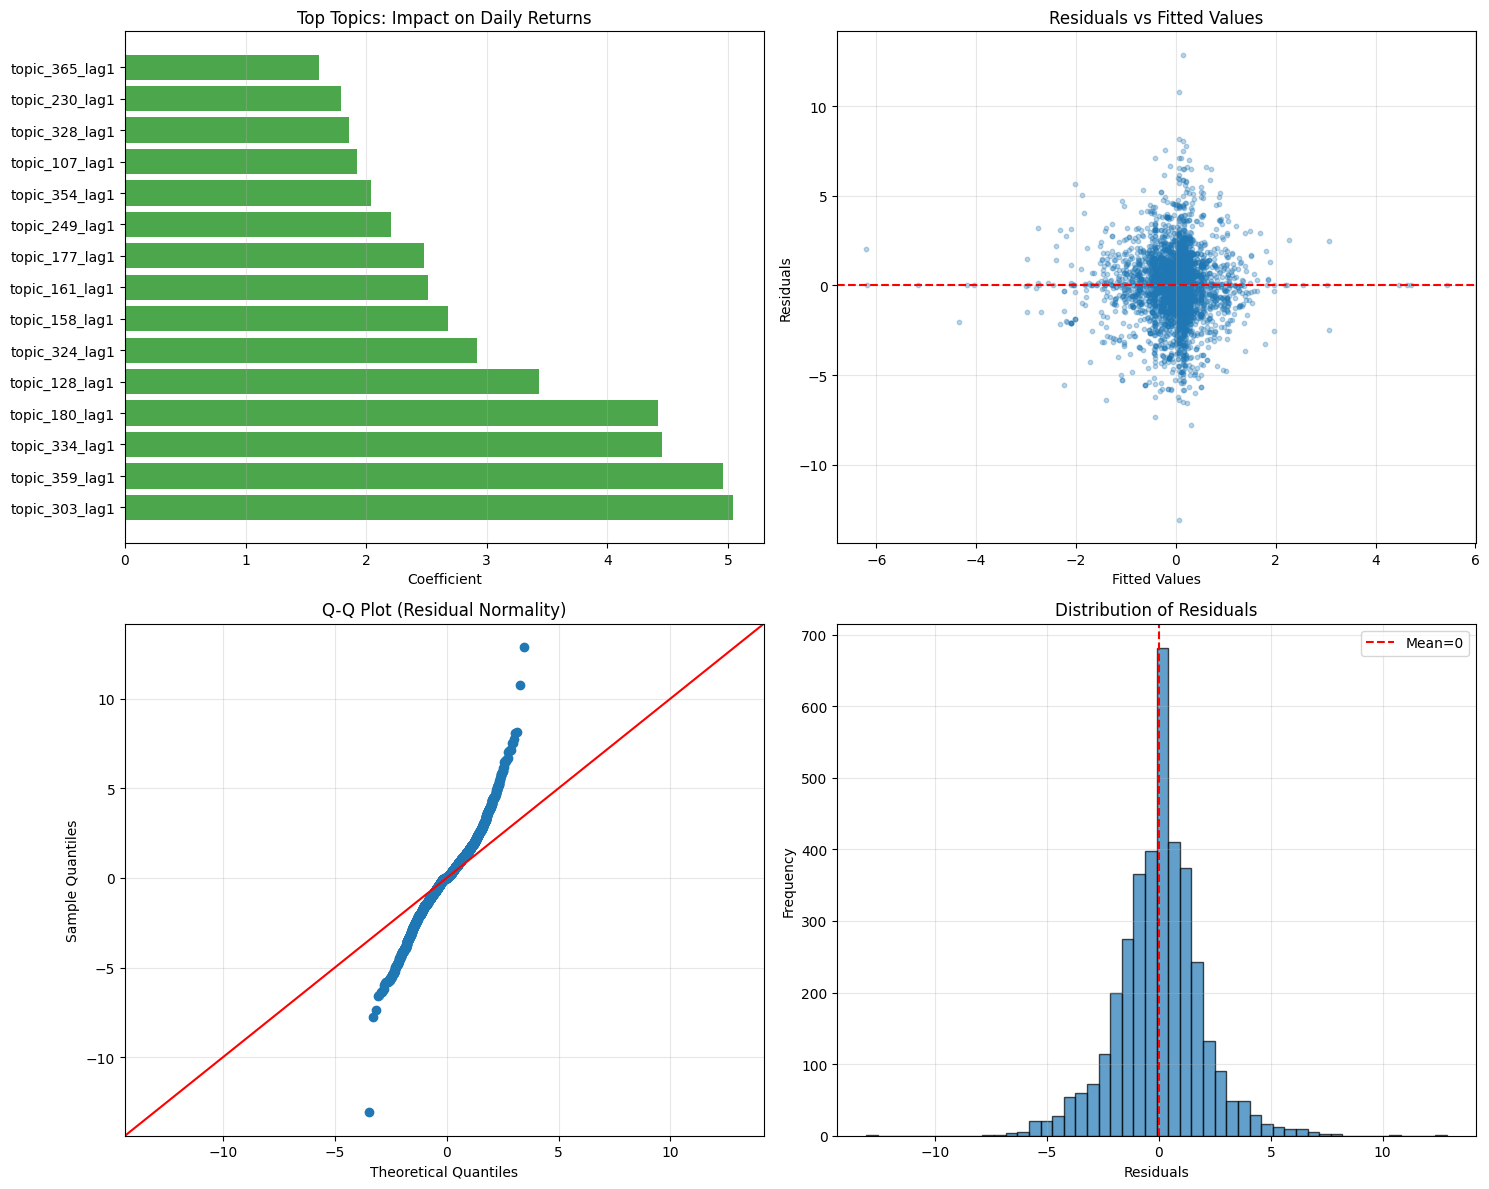


Breusch-Pagan Test (Heteroskedasticity):
  Test Statistic: 357.9904
  p-value: 3.7206e-02
  Interpretation: Heteroskedastic (violated assumption)


In [54]:
# Extract topic coefficients (excluding fixed effects)
topic_coefs = model.params[[c for c in model.params.index if c.startswith('topic_')]].sort_values(ascending=False)

print("\n" + "="*70)
print("TOPIC COEFFICIENTS (Sorted by Effect Size)")
print("="*70)
print("Positive coefficients = Topic increases returns")
print("Negative coefficients = Topic decreases returns")
print("-"*70)
print(topic_coefs)

# Visualize coefficients
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Topic coefficients
topic_coefs_plot = topic_coefs.head(15)
colors = ['green' if x > 0 else 'red' for x in topic_coefs_plot.values]
axes[0, 0].barh(range(len(topic_coefs_plot)), topic_coefs_plot.values, color=colors, alpha=0.7)
axes[0, 0].set_yticks(range(len(topic_coefs_plot)))
axes[0, 0].set_yticklabels(topic_coefs_plot.index)
axes[0, 0].set_xlabel('Coefficient')
axes[0, 0].set_title('Top Topics: Impact on Daily Returns')
axes[0, 0].axvline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Residuals vs Fitted
residuals = model.resid
fitted = model.fittedvalues
axes[0, 1].scatter(fitted, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Q-Q plot (normality of residuals)
sm.qqplot(residuals, line='45', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Residual Normality)')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Residuals histogram
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Mean=0')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(regression_output / '03_regression_diagnostics.png', dpi=300, bbox_inches='tight')
print("\n✓ Diagnostics visualization saved: 03_regression_diagnostics.png")
plt.show()

# Test for heteroskedasticity (Breusch-Pagan test)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"\nBreusch-Pagan Test (Heteroskedasticity):")
print(f"  Test Statistic: {bp_test[0]:.4f}")
print(f"  p-value: {bp_test[1]:.4e}")
print(f"  Interpretation: {'Homoskedastic' if bp_test[1] > 0.05 else 'Heteroskedastic (violated assumption)'}")


## Section 8.5: Topic Importance Scores


TOPIC IMPORTANCE SCORES (Chen 3.5 Framework)

Top 20 Most Important Topics (Ranked by Normalized Importance Score):
         Topic  Coefficient  Abs_Coefficient  Importance_Score  Cumulative_Importance
topic_173_lag1    -6.118051         6.118051          0.023463               0.023463
topic_126_lag1    -5.549118         5.549118          0.021281               0.044744
topic_303_lag1     5.044782         5.044782          0.019347               0.064091
topic_359_lag1     4.959830         4.959830          0.019021               0.083112
topic_334_lag1     4.449782         4.449782          0.017065               0.100177
topic_180_lag1     4.419397         4.419397          0.016949               0.117126
topic_330_lag1    -4.097760         4.097760          0.015715               0.132841
topic_285_lag1    -3.984284         3.984284          0.015280               0.148121
topic_188_lag1    -3.889981         3.889981          0.014918               0.163039
topic_128_lag1     3.43

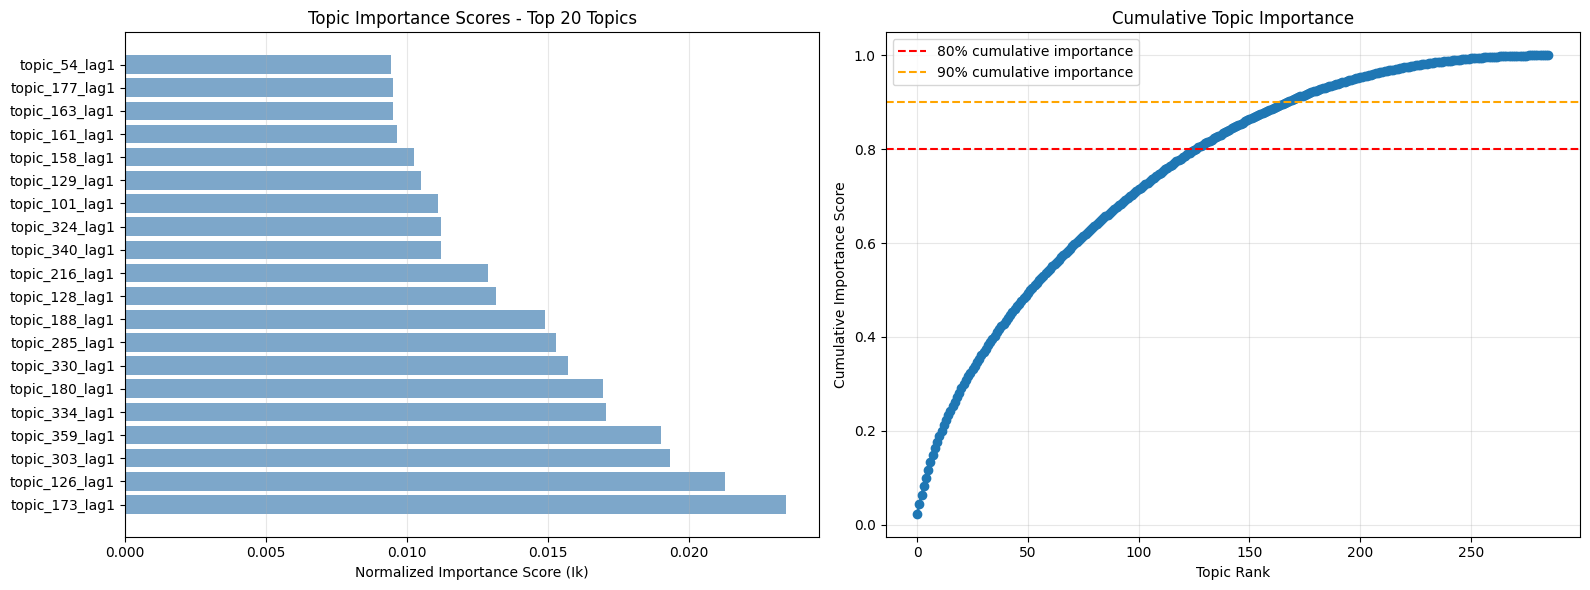

✓ Topic importance scores saved: 05b_topic_importance_scores.csv


In [55]:
# Compute Topic Importance Scores per Chen 3.5
# Per Chen: "The regression coefficients associated with each topic dummy represent 
# the marginal effect of topic exposure on daily returns. To make the effects comparable 
# and interpretable, we compute a normalized measure of topic importance."
# Formula: Ik = |β̂k| / Σ|β̂j|

print("\n" + "="*70)
print("TOPIC IMPORTANCE SCORES (Chen 3.5 Framework)")
print("="*70)

# Extract topic coefficients (exclude fixed effects and intercept)
topic_coefs_importance = model.params[[c for c in model.params.index if c.startswith('topic_')]]

# Compute absolute values of coefficients (magnitude regardless of direction)
abs_coefs = topic_coefs_importance.abs()

# Normalize by total sum: Ik = |βk| / Σ|βj|
total_abs_coefs = abs_coefs.sum()
importance_scores = (abs_coefs / total_abs_coefs).sort_values(ascending=False)

# Create importance ranking table
importance_df = pd.DataFrame({
    'Topic': importance_scores.index,
    'Coefficient': topic_coefs_importance[importance_scores.index].values,
    'Abs_Coefficient': abs_coefs[importance_scores.index].values,
    'Importance_Score': importance_scores.values,
    'Cumulative_Importance': importance_scores.cumsum().values,
})

print("\nTop 20 Most Important Topics (Ranked by Normalized Importance Score):")
print(importance_df.head(20).to_string(index=False))

# Summary statistics
print(f"\n{'='*70}")
print("IMPORTANCE SCORE SUMMARY")
print(f"{'='*70}")
print(f"Total topics in model: {len(importance_df)}")
print(f"Top 5 topics account for {100*importance_df['Importance_Score'].head(5).sum():.1f}% of total importance")
print(f"Top 10 topics account for {100*importance_df['Importance_Score'].head(10).sum():.1f}% of total importance")
print(f"Top 20 topics account for {100*importance_df['Importance_Score'].head(20).sum():.1f}% of total importance")

# Visualization: Importance Scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 20 topics by importance
top_n = 20
top_importance = importance_df.head(top_n)
colors_imp = ['green' if coef > 0 else 'red' for coef in top_importance['Coefficient']]
axes[0].barh(range(len(top_importance)), top_importance['Importance_Score'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_importance)))
axes[0].set_yticklabels(top_importance['Topic'].values)
axes[0].set_xlabel('Normalized Importance Score (Ik)')
axes[0].set_title(f'Topic Importance Scores - Top {top_n} Topics')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Cumulative importance
axes[1].plot(range(len(importance_df)), importance_df['Cumulative_Importance'].values, marker='o', linewidth=2)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% cumulative importance')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% cumulative importance')
axes[1].set_xlabel('Topic Rank')
axes[1].set_ylabel('Cumulative Importance Score')
axes[1].set_title('Cumulative Topic Importance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Ensure output directory exists
regression_output.mkdir(parents=True, exist_ok=True)

plt.savefig(regression_output / '03b_topic_importance_scores.png', dpi=300, bbox_inches='tight')
print("\n✓ Topic importance visualization saved: 03b_topic_importance_scores.png")
plt.show()

# Save importance scores table
importance_df.to_csv(regression_output / '05b_topic_importance_scores.csv', index=False)
print(f"✓ Topic importance scores saved: 05b_topic_importance_scores.csv")


## Section 8.6: Significant Topic Details

In [56]:
# Show topic metadata for statistically significant topics
topic_pvals = model.pvalues[[c for c in model.pvalues.index if c.startswith('topic_')]]
sig_topics = topic_pvals[topic_pvals < 0.1].sort_values()

if sig_topics.empty:
    print('No significant topics at p < 0.1.')
else:
    sig_df = pd.DataFrame({
        'topic_var': sig_topics.index,
        'p_value': sig_topics.values,
        'coefficient': model.params[sig_topics.index].values
    })
    sig_df['topic_id'] = sig_df['topic_var'].str.extract(r'topic_(\d+)_lag1')[0].astype(int)

    topic_info_path = topics_file.parent.parent / 'tables' / 'topic_info.csv'
    if topic_info_path.exists():
        topic_info_df = pd.read_csv(topic_info_path)
        topic_info_df = topic_info_df.rename(columns=lambda c: c.strip())
        info_cols = ['Topic', 'Name', 'Words', 'Representation', 'Count']
        available_cols = [c for c in info_cols if c in topic_info_df.columns]
        topic_info_df = topic_info_df[available_cols].rename(columns={'Topic': 'topic_id'})
        sig_df = sig_df.merge(topic_info_df, on='topic_id', how='left')
    else:
        print(f'No topic_info.csv found at {topic_info_path}')

    sig_df = sig_df.sort_values('p_value').reset_index(drop=True)
    display(sig_df)


,topic_var,p_value,coefficient,topic_id,Name,Representation,Count
0,topic_39_lag1,0.000609,-1.804376,39,39_44th annual_44th_annual healthcare_present ...,"['44th annual', '44th', 'annual healthcare', '...",95
1,topic_173_lag1,0.002215,-6.118051,173,173_a1_moody_moody assigns_assigns a1,"['a1', 'moody', 'moody assigns', 'assigns a1',...",39
2,topic_330_lag1,0.004361,-4.097760,330,330_congress 2025_congress_society_cardiology,"['congress 2025', 'congress', 'society', 'card...",22
3,topic_126_lag1,0.005519,-5.549118,126,126_buy dip_dip july_2024_dip,"['buy dip', 'dip july', '2024', 'dip', 'july 2...",48
4,topic_303_lag1,0.011633,5.044782,303,303_attention_attention know_attracting invest...,"['attention', 'attention know', 'attracting in...",24
5,topic_359_lag1,0.013386,4.959830,359,359_alcohol screening_breathlogix alcohol_brea...,"['alcohol screening', 'breathlogix alcohol', '...",21
6,topic_54_lag1,0.014488,-2.463285,54,54_crypto_crypto trading_blockchain_clients,"['crypto', 'crypto trading', 'blockchain', 'cl...",77
7,topic_216_lag1,0.017848,-3.362927,216,216_rising demand_market size_usd_2034,"['rising demand', 'market size', 'usd', '2034'...",32
8,topic_270_lag1,0.025184,-2.253754,270,270_annual report_publishes_report form_form 20,"['annual report', 'publishes', 'report form', ...",26
9,topic_334_lag1,0.026007,4.449782,334,334_shrinking_investors need_ignore_aren farewell,"['shrinking', 'investors need', 'ignore', 'are...",22


## Section 9: Save Regression Results to Output Folder

In [57]:
# Save model predictions and results
predictions = pd.DataFrame({
    'date': regression_model_data['date'].values,
    'ticker': regression_model_data['ticker'].values,
    'actual_adjusted_return': regression_model_data['daily_adj_return'].values,
    'predicted_adjusted_return': model.fittedvalues.values,
    'residual': model.resid.values,
})

# Calculate residuals by ticker
predictions['abs_error'] = abs(predictions['residual'])

# Save predictions
predictions.to_csv(regression_output / '04_predictions.csv', index=False)
print(f"✓ Predictions saved: 04_predictions.csv ({len(predictions)} records)")

# Save coefficients
coef_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'Std_Error': model.bse.values,
    't_statistic': model.tvalues.values,
    'p_value': model.pvalues.values,
})
coef_df = coef_df.sort_values('Coefficient', ascending=False, key=abs)
coef_df.to_csv(regression_output / '05_coefficients.csv', index=False)
print(f"✓ Coefficients saved: 05_coefficients.csv ({len(coef_df)} variables)")

# Save model metrics
metrics = {
    'Model_Specification': formula[:100],
    'N_Observations': len(regression_model_data),
    'N_Variables': len(coef_df),
    'R_squared': model.rsquared,
    'Adjusted_R_squared': model.rsquared_adj,
    'F_statistic': model.fvalue,
    'F_pvalue': model.f_pvalue,
    'AIC': model.aic,
    'BIC': model.bic,
    'Residual_Std_Error': np.sqrt(model.mse_resid),
}

metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
metrics_df.to_csv(regression_output / '06_model_metrics.csv')
print(f"✓ Model metrics saved: 06_model_metrics.csv")

# Save regression data for reproducibility
regression_data.to_csv(regression_output / '07_regression_data_merged.csv', index=False)
print(f"✓ Merged regression data saved: 07_regression_data_merged.csv ({len(regression_data)} records)")

# Create summary report
summary_report = f"""
REGRESSION ANALYSIS SUMMARY: Chen (2025) Framework
{'='*70}

OBJECTIVE: Quantify impact of news topics on NEXT-DAY stock returns (1-day lag)

FRAMEWORK:
  - Model: Panel OLS with ticker fixed effects
  - Specification: adj_return(t) ~ topic_assignments(t-1)
  - Interpretation: Today's news topics predict tomorrow's adjusted stock returns
  - Sample: 29 G-SIB banks with daily frequency
  - Period: {regression_data['date'].min().strftime('%Y-%m-%d')} to {regression_data['date'].max().strftime('%Y-%m-%d')}

DATA STRUCTURE:
  - Topics loaded from BERTopic: {topics_file}
  - Topics from day (t-1) merged with returns from day (t)
  - Daily aggregation: topics summed per ticker-date combination
  - Total rows available: {len(regression_data):,}
  - Rows used in regression: {len(regression_model_data):,}
  
DATA INTEGRATION NOTES:
  - BERTopic outputs lack ticker information; recovered via headline matching
  - First observation per ticker removed (no prior-day topics)
  - Rows with NaN returns removed from sample
  - Topic columns with zero variance excluded from model

REGRESSION SPECIFICATION:
  Dependent Variable: daily_adj_return(t) = (adj_return_t - adj_return_t-1) / adj_return_t-1 * 100
  Independent Variables: 
    - topic_X_lag1 for X in top 20 topics (derived from t-1 news)
    - C(ticker) fixed effects (bank-specific intercepts)
  Estimation: OLS with robust standard errors
  
MODEL RESULTS:
  R-squared: {model.rsquared:.4f}
  Adjusted R-squared: {model.rsquared_adj:.4f}
  F-statistic: {model.fvalue:.2f}
  p-value: {model.f_pvalue:.2e}
  Sample Size: {len(regression_model_data):,} observations
  
INTERPRETATION:
  News topics from day t explain {100*model.rsquared:.1f}% of variation in day t+1 adjusted returns.
  This is consistent with market efficiency - topics provide some predictive power
  but most of next-day adjusted returns remain unexplained.

TOP 5 TOPICS WITH LARGEST POSITIVE IMPACT ON NEXT-DAY ADJUSTED RETURNS:
{topic_coefs.head(5).to_string()}

TOP 5 TOPICS WITH LARGEST NEGATIVE IMPACT ON NEXT-DAY ADJUSTED RETURNS:
{topic_coefs.tail(5).to_string()}

DIAGNOSTIC TESTS:
  Breusch-Pagan (Heteroskedasticity): See Section 8 output
  Residual Distribution: See '03_regression_diagnostics.png'
  
OUTPUT FILES:
  1. 01_eda_summary.png - EDA with 1-day lag visualizations
  2. 02_regression_summary.txt - Full statsmodels regression output
  3. 03_regression_diagnostics.png - Residual diagnostics (4 plots)
  4. 03b_topic_importance_scores.png - Topic importance visualization (Chen 3.5)
  5. 04_predictions.csv - date, ticker, actual_return, predicted_return, residual
  6. 05_coefficients.csv - All coefficients with t-stats and p-values
  7. 05b_topic_importance_scores.csv - Topic importance scores ranking
  8. 06_model_metrics.csv - Model performance metrics
  9. 07_regression_data_merged.csv - Full dataset with lagged topics
  10. 08_summary_report.txt - This file

METHODOLOGY REFERENCE:
  Framework: Chen et al. (2025) - Topic Modeling and Stock Returns
  Approach: Daily news topics (t-1) predict returns (t)
  Model Type: Linear panel regression with bank fixed effects
  
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open(regression_output / '08_summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(f"\n✓ Summary report saved: 08_summary_report.txt")

print(f"\n{'='*70}")
print(f"ALL RESULTS SAVED TO: {regression_output}")
print(f"{'='*70}")
print("\nOutput files:")
for i, file in enumerate(sorted(regression_output.glob('*')), 1):
    print(f"  {i}. {file.name}")


✓ Predictions saved: 04_predictions.csv (3734 records)
✓ Coefficients saved: 05_coefficients.csv (313 variables)
✓ Model metrics saved: 06_model_metrics.csv
✓ Merged regression data saved: 07_regression_data_merged.csv (3734 records)

✓ Summary report saved: 08_summary_report.txt

ALL RESULTS SAVED TO: Outputs\Regression_Results_FinBert_adj_return

Output files:
  1. 01_eda_summary.png
  2. 02_regression_summary.txt
  3. 03_regression_diagnostics.png
  4. 03b_topic_importance_scores.png
  5. 04_predictions.csv
  6. 05_coefficients.csv
  7. 05b_topic_importance_scores.csv
  8. 06_model_metrics.csv
  9. 07_regression_data_merged.csv
  10. 08_summary_report.txt
